In [1]:
import Nodes
import numpy as np
import matplotlib.pyplot as plt
import aux_func as aux

r_teste = [-1.0, 0.0, 1.0, 0.5]
s_teste = [0.0, 0.5, 1.0, -1.0]

a_res, b_res = Nodes.rstoab(r_teste, s_teste)

print("Vetor r original:", r_teste)
print("Vetor s original:", s_teste)
print("-" * 30)
print("Resultado a:", a_res)
print("Resultado b:", b_res)

Vetor r original: [-1.0, 0.0, 1.0, 0.5]
Vetor s original: [0.0, 0.5, 1.0, -1.0]
------------------------------
Resultado a: [-1.   3.  -1.   0.5]
Resultado b: [ 0.   0.5  1.  -1. ]


--- Teste Numérico ---
Warp em r = -1.0 : 0.000000000000000 (Esperado: 0.0)
Warp em r =  1.0 : 0.000000000000000 (Esperado: 0.0)
Sucesso: Os limites do domínio estão ancorados corretamente.



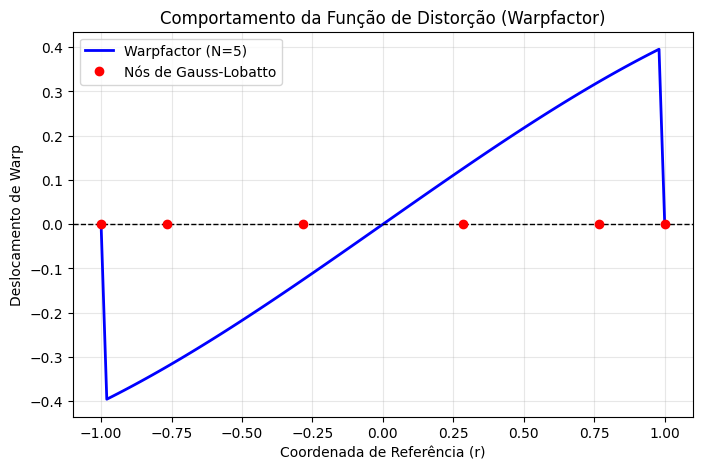

In [2]:
# Se as suas funções estiverem em outro arquivo (ex: aux.py), importe-as. 
# Caso contrário, certifique-se de que estão definidas acima deste bloco.

def testar_warpfactor():
    N = 5 # Ordem do polinômio para o teste
    
    # ---------------------------------------------------------
    # TESTE 1: Verificação Numérica Extrema (Casos Críticos)
    # ---------------------------------------------------------
    pontos_criticos = np.array([-1.0, 0.0, 1.0])
    warp_critico = Nodes.Warpfactor(N, pontos_criticos)
    
    print("--- Teste Numérico ---")
    print(f"Warp em r = -1.0 : {warp_critico[0]:.15f} (Esperado: 0.0)")
    print(f"Warp em r =  1.0 : {warp_critico[2]:.15f} (Esperado: 0.0)")
    
    # Validação automática
    assert np.isclose(warp_critico[0], 0.0), "Erro: O warp em -1 não é zero!"
    assert np.isclose(warp_critico[2], 0.0), "Erro: O warp em 1 não é zero!"
    print("Sucesso: Os limites do domínio estão ancorados corretamente.\n")

    # ---------------------------------------------------------
    # TESTE 2: Verificação Visual (Curva de Distorção)
    # ---------------------------------------------------------
    # Cria 100 pontos de alta resolução para plotar uma curva suave
    r_alta_resolucao = np.linspace(-1, 1, 100)
    warp_curva = Nodes.Warpfactor(N, r_alta_resolucao)
    
    # Plota o resultado
    plt.figure(figsize=(8, 5))
    plt.plot(r_alta_resolucao, warp_curva, 'b-', linewidth=2, label=f'Warpfactor (N={N})')
    
    # Marcação visual do zero
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Marca os pontos exatos de Gauss-Lobatto no eixo para referência
    LGL_pontos = aux.JacobiGL(0, 0, N) # Lembre-se de ajustar o 'aux.' se necessário
    plt.plot(LGL_pontos, np.zeros_like(LGL_pontos), 'ro', label='Nós de Gauss-Lobatto')
    
    plt.title("Comportamento da Função de Distorção (Warpfactor)")
    plt.xlabel("Coordenada de Referência (r)")
    plt.ylabel("Deslocamento de Warp")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Executa o teste
testar_warpfactor()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


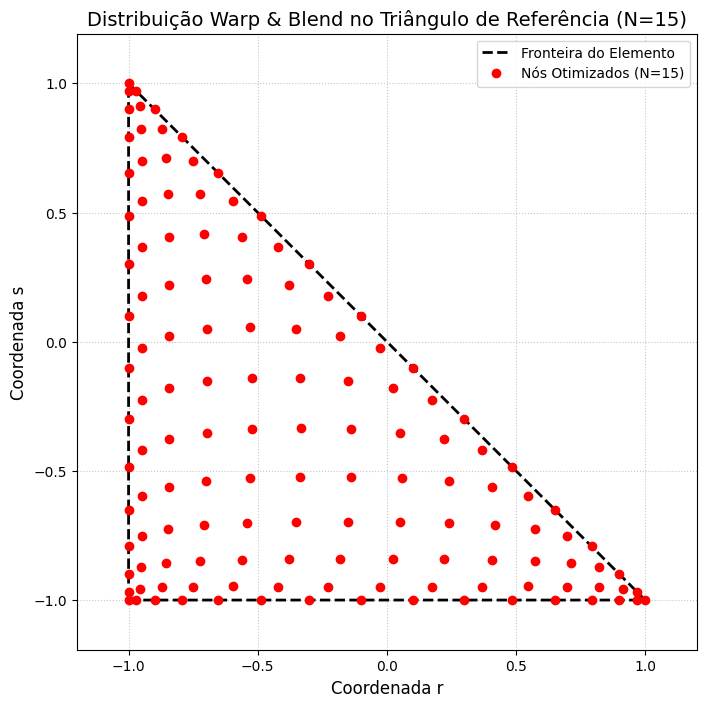

In [3]:
def plotar_malha_triangulo(N):
    # 1. Calcula os nós usando as suas funções corrigidas
    x, y = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x, y)
    
    # 2. Prepara a figura
    plt.figure(figsize=(8, 8))
    
    # 3. Desenha as bordas do triângulo de referência para checagem visual
    # Conecta os pontos: (-1,-1) -> (1,-1) -> (-1,1) -> volta pro (-1,-1)
    r_borda = [-1.0,  1.0, -1.0, -1.0]
    s_borda = [-1.0, -1.0,  1.0, -1.0]
    plt.plot(r_borda, s_borda, 'k--', linewidth=2, label='Fronteira do Elemento')
    
    # 4. Plota os nós que você calculou
    plt.plot(r, s, 'ro', markersize=6, label=f'Nós Otimizados (N={N})')
    
    # 5. Ajustes estéticos cruciais
    plt.axis('equal')  # Garante que as proporções geométricas sejam reais
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    
    # Textos e legendas
    plt.title(f"Distribuição Warp & Blend no Triângulo de Referência (N={N})", fontsize=14)
    plt.xlabel("Coordenada r", fontsize=12)
    plt.ylabel("Coordenada s", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    
    plt.show()

# Faça o teste! Uma ordem N=6 ou N=8 costuma ficar com um visual bem legal.
plotar_malha_triangulo(N=15)

In [4]:
import numpy as np
import operators2D as op2D

def testar_condicao_vandermonde():
    print("Testando o Número de Condição da Matriz de Vandermonde 2D")
    print("-" * 55)
    print(f"{'Ordem (N)':<12} | {'Tamanho (Np)':<15} | {'Num. Condição':<20}")
    print("-" * 55)
    
    # Testa para ordens de 1 a 10
    for N in range(1, 11):
        # 1. Obtém os nós x, y otimizados (Warp & Blend)
        x, y = Nodes.Nodes2D(N)
        
        # 2. Transforma para as coordenadas do triângulo de referência r, s
        r, s = Nodes.xytors(x, y)
        
        # 3. Constrói a Matriz de Vandermonde 2D
        V = op2D.Vandermonde2D(N, r, s)
        
        # 4. Calcula o número de condição (razão entre maior e menor valor singular)
        cond_number = np.linalg.cond(V)
        
        # Tamanho do vetor (linhas/colunas da matriz quadrada V)
        Np = int((N + 1) * (N + 2) / 2)
        
        print(f"{N:<12} | {Np:<15} | {cond_number:<20.4f}")
        
    print("-" * 55)

# Executa o teste
testar_condicao_vandermonde()

Testando o Número de Condição da Matriz de Vandermonde 2D
-------------------------------------------------------
Ordem (N)    | Tamanho (Np)    | Num. Condição       
-------------------------------------------------------
1            | 3               | 2.0000              
2            | 6               | 4.1483              
3            | 10              | 5.9028              
4            | 15              | 6.7808              
5            | 21              | 8.0842              
6            | 28              | 9.5819              
7            | 36              | 11.2023             
8            | 45              | 13.9515             
9            | 55              | 17.0483             
10           | 66              | 21.7140             
-------------------------------------------------------


In [5]:
import numpy as np
import operators2D as op2D

def testar_matrizes_derivacao(N=3):
    print(f"--- Testando Matrizes D (Ordem N={N}) ---")
    
    # 1. Gera a malha e as coordenadas r, s
    x, y = Nodes.Nodes2D(N) # Ajuste para Nodes.Nodes2D se estiver em outro arquivo
    r, s = Nodes.xytors(x, y)
    
    # 2. Constrói a Matriz de Vandermonde e as Matrizes D
    V = op2D.Vandermonde2D(N, r, s)
    Dr, Ds =op2D.Dmatrices2D(N, r, s, V)
    
    # 3. Define a função de teste: f(r,s) = r^2 + s^3
    f_val = r**2 + s**3
    
    # 4. Derivadas Analíticas (Exatas)
    dfdr_exato = 2 * r
    dfds_exato = 3 * s**2
    
    # 5. Derivadas Numéricas (Usando as suas matrizes!)
    dfdr_num = Dr @ f_val
    dfds_num = Ds @ f_val
    
    # 6. Calcula o erro absoluto máximo entre a matriz e o cálculo exato
    erro_r = np.max(np.abs(dfdr_num - dfdr_exato))
    erro_s = np.max(np.abs(dfds_num - dfds_exato))
    
    print(f"Erro máximo na derivada em r (Dr): {erro_r:.3e}")
    print(f"Erro máximo na derivada em s (Ds): {erro_s:.3e}")
    
    # Validação automática
    limiar = 1e-12
    if erro_r < limiar and erro_s < limiar:
        print("\nSUCESSO ABSOLUTO! 🎉")
        print("Suas matrizes diferenciam polinômios com precisão de máquina.")
    else:
        print("\nALERTA: O erro está muito alto. Verifique as funções anteriores.")

# Executa o teste
testar_matrizes_derivacao(N=3)

--- Testando Matrizes D (Ordem N=3) ---
Erro máximo na derivada em r (Dr): 1.332e-15
Erro máximo na derivada em s (Ds): 3.997e-15

SUCESSO ABSOLUTO! 🎉
Suas matrizes diferenciam polinômios com precisão de máquina.


In [6]:
import numpy as np

def testar_filtro2d(N=5, Nc=3, ordem_filtro=4):
    print(f"--- Testando Filtro 2D (N={N}, Corte Nc={Nc}) ---")
    
    # 1. Gera a malha geométrica
    x, y = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x, y)
    
    # 2. Matriz de Vandermonde e sua inversa
    V = op2D.Vandermonde2D(N, r, s)
    invV = np.linalg.inv(V)
    
    # 3. Constrói a Matriz de Filtro
    F = op2D.Filter2D(N, Nc, ordem_filtro, V)
    
    # 4. Cria um "sinal" ruidoso aleatório nos nós da malha
    np.random.seed(42) # Semente fixa para podermos reproduzir o mesmo teste
    u_nodal = np.random.rand(len(r))
    
    # 5. APLICA O FILTRO!
    u_filtrado = F @ u_nodal
    
    # 6. Analisando o resultado no Espaço Modal (Frequências)
    # Multiplicar por invV nos dá os coeficientes dos polinômios de Jacobi
    modos_originais = invV @ u_nodal
    modos_filtrados = invV @ u_filtrado
    
    # 7. Imprime a tabela de comparação
    print(f"\n{'Índice':<6} | {'Ordem (i+j)':<12} | {'Modo Original':<15} | {'Modo Filtrado':<15} | {'Atenuação'}")
    print("-" * 75)
    
    sk = 0
    for i in range(N + 1):
        for j in range(N - i + 1):
            ordem_modo = i + j
            orig = modos_originais[sk]
            filt = modos_filtrados[sk]
            
            # Calcula a porcentagem que restou do sinal
            if abs(orig) > 1e-14:
                razao = (filt / orig) * 100
            else:
                razao = 100.0
                
            # Destaca visualmente se o modo sofreu corte
            status = "Intacto" if ordem_modo < Nc else f"{razao:>6.2f}%"
            
            print(f"{sk:<6} | {ordem_modo:<12} | {orig:>15.4f} | {filt:>15.4f} | {status}")
            sk += 1

# Executa o teste
testar_filtro2d(N=5, Nc=3, ordem_filtro=4)

--- Testando Filtro 2D (N=5, Corte Nc=3) ---

Índice | Ordem (i+j)  | Modo Original   | Modo Filtrado   | Atenuação
---------------------------------------------------------------------------
0      | 0            |          0.7824 |          0.7824 | Intacto
1      | 1            |         -0.1415 |         -0.1415 | Intacto
2      | 2            |         -0.0279 |         -0.0279 | Intacto
3      | 3            |          0.0760 |          0.0760 | 100.00%
4      | 4            |          0.0157 |          0.0016 |  10.51%
5      | 5            |         -0.0106 |         -0.0000 |   0.00%
6      | 1            |         -0.1951 |         -0.1951 | Intacto
7      | 2            |         -0.0997 |         -0.0997 | Intacto
8      | 3            |          0.0869 |          0.0869 | 100.00%
9      | 4            |          0.0756 |          0.0080 |  10.51%
10     | 5            |         -0.0926 |          0.0000 |  -0.00%
11     | 2            |         -0.0529 |         -0.0529 | 

In [8]:
import numpy as np

import numpy as np

def calcular_fmask(r, s, tol=1e-10):
    """
    Constrói a matriz de índices Fmask para o triângulo de referência.
    Retorna uma matriz onde cada coluna contém os índices dos nós 
    pertencentes a uma das faces.
    """
    # 1. Encontra os índices (IDs) dos pontos que satisfazem a geometria da face
    # O [0] no final serve para extrair o array de dentro da tupla que o np.where retorna
    fmask1 = np.where(np.abs(s + 1.0) < tol)[0]  # Face 1: s = -1
    fmask2 = np.where(np.abs(r + s) < tol)[0]    # Face 2: r + s = 0
    fmask3 = np.where(np.abs(r + 1.0) < tol)[0]  # Face 3: r = -1
    
    # 2. Agrupa as três listas como colunas em uma matriz 2D
    # O resultado será uma matriz de tamanho (Nfp, 3)
    Fmask = np.column_stack((fmask1, fmask2, fmask3))
    
    return Fmask

def testar_lift2d(N=4):
    print(f"--- Testando Matriz LIFT (Ordem N={N}) ---")
    
    # 1. Gera a geometria básica
    # (Ajuste para Nodes.Nodes2D, etc., dependendo de como você organizou os arquivos)
    x, y = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x, y)
    Fmask = calcular_fmask(r, s)
    
    # 2. Constrói a Matriz de Vandermonde e a Matriz de Massa 2D
    V = op2D.Vandermonde2D(N, r, s)
    M = np.linalg.inv(V @ V.T)  # Matriz de Massa do Volume
    
    # 3. Calcula a Matriz LIFT usando a função que corrigimos
    LIFT = op2D.Lift2D(N, r, s, V)
    
    # 4. O TESTE DO TEOREMA DE GAUSS
    Nfp = N + 1
    # Cria um vetor de "1"s representando um fluxo constante e unitário nas 3 faces
    fluxo_faces = np.ones(3 * Nfp)
    
    # "Levanta" esse fluxo das bordas para o volume do triângulo
    fluxo_volume = LIFT @ fluxo_faces
    
    # Integra o fluxo levantado em todo o volume do triângulo
    # Em métodos espectrais, multiplicar por M e somar tudo é o equivalente numérico de ∫f(x)dx
    integral_volume = np.sum(M @ fluxo_volume)
    
    # 5. Exibe os resultados
    print(f"Integral de Volume Computada : {integral_volume:.14f}")
    print(f"Valor Analítico Esperado     : 6.00000000000000")
    
    erro = abs(integral_volume - 6.0)
    print(f"Erro Absoluto                : {erro:.3e}")
    
    if erro < 1e-12:
        print("\nSUCESSO ABSOLUTO! 🎉")
        print("A sua matriz LIFT está conectando as faces ao volume com precisão de máquina.")
    else:
        print("\nALERTA: O valor não bateu. Verifique as indexações e matrizes 1D no Lift2D.")

# Executa o teste
testar_lift2d(N=4)

--- Testando Matriz LIFT (Ordem N=4) ---
Integral de Volume Computada : 6.00000000000000
Valor Analítico Esperado     : 6.00000000000000
Erro Absoluto                : 0.000e+00

SUCESSO ABSOLUTO! 🎉
A sua matriz LIFT está conectando as faces ao volume com precisão de máquina.
